## Clustering

Clustering is an unsupervised learning approach used to group similar data points together based on their inherent characteristics. The goal is to identify patterns and structures in the dataset without prior knowledge of the labels. In this project, we hope to use clustering to discover meaningful subgroups within the patient population, which could help in understanding differences in treatment responses or outcomes, and potentially reveal patient phenotypes that benefit from specific interventions.


Table of contents
- 0. Prepare the Jupyter Notebook
- 1. Standardization or Normalization
- 2. Kmeans clustering

### 0. Preparing the Jupyter Notebook

To begin, we load the necessary libraries and import the prepared dataset. We will use **`patient_data_onehot_imputed`** as it already includes all preprocessing steps required for machine learning, except for **normalization or standardization**. This ensures we have a consistent and clean dataset ready for further analysis.


In [1]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import json

from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.metrics import calinski_harabasz_score


In [2]:
# Loading the dataset
ART = Path("artifacts")
data = np.load(ART/"dataset_prepared.npz", allow_pickle=True)

# Tabular (preprocessed, dense)
X_tab_train = data["X_tab_train"]; X_tab_val = data["X_tab_val"]; X_tab_test = data["X_tab_test"]
y_train     = data["y_train"];     y_val     = data["y_val"];     y_test     = data["y_test"]

# Full tabular for exploratory clustering
X_full = np.vstack([X_tab_train, X_tab_val, X_tab_test])
y_full = np.concatenate([y_train, y_val, y_test])

# Feature names
feat_names = json.load(open(ART/"feature_names.json"))["tab"]
df_full = pd.DataFrame(X_full, columns=feat_names)
df_full["outcome"] = y_full  # 1=Good, 0=Poor
df_full.head()

,rosc__rosc,nums__age,cats__hospital_A,cats__hospital_B,cats__hospital_D,cats__hospital_E,cats__hospital_F,cats__sex_Female,cats__sex_Male,cats__sex_nan,cats__ohca_False,cats__ohca_True,cats__ohca_Unknown,cats__shockable_rhythm_False,cats__shockable_rhythm_True,cats__shockable_rhythm_Unknown,cats__ttm_33.0,cats__ttm_36.0,cats__ttm_No TTM,outcome
0,-0.489125,1.409359,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
1,-0.141507,-1.449509,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
2,-0.489125,1.864179,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
3,-0.141507,-0.409920,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
4,0.553729,-1.644431,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1


In [3]:
desc = df_full.drop(columns="outcome").describe().T[["mean","std"]].sort_values("std", ascending=False)
desc.head(20)


,mean,std
nums__age,-0.009123,1.016031
rosc__rosc,-0.028116,0.929379
cats__shockable_rhythm_True,0.489292,0.500298
cats__shockable_rhythm_False,0.457990,0.498643
cats__hospital_A,0.429984,0.495482
cats__sex_Male,0.686985,0.464103
cats__sex_Female,0.308072,0.462077
cats__ohca_True,0.728171,0.445269
cats__ttm_33.0,0.738056,0.440055
cats__ohca_False,0.204283,0.403509


In [4]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3, random_state=42)
X_pca3 = pca.fit_transform(X_full)
print("Explained variance (3 PCs):", pca.explained_variance_ratio_.round(3), "Sum:", round(pca.explained_variance_ratio_.sum(), 3))


Explained variance (3 PCs): [0.245 0.187 0.141] Sum: 0.573


#### Selecting Data for the Machine Learning Component from the Original DataFrame

We are now selecting the relevant features, including the transformed `rosc` data, from the original DataFrame. This subset will be placed into a new DataFrame, `machine_learning_df`, for clearer separation and easier manipulation during model training. We can experiment with the included features as needed to optimize model performance.

Based on the findings in **02_Feature_Importance**, we concluded that hospital identifiers are not relevant for our model. This aligns with the medical perspective, as our focus should remain on patient-related features. For now, we will retain the other features and proceed with the Box-Cox transformed `rosc`.

In [5]:
hospital_cols = [c for c in df_full.columns if c.startswith("cats__hospital_")]


In [6]:
# === 1. Exclude hospital columns ===
hosp_cols = [c for c in df_full.columns if c.startswith("cats__hospital_")]
df_nohosp = df_full.drop(columns=hosp_cols, errors="ignore")

# === 2. Split into ALL and TTM-only ===
X_all = df_nohosp.drop(columns=["outcome"], errors="ignore")

if "cats__ttm_No TTM" in X_all.columns:
    mask_ttm = X_all["cats__ttm_No TTM"] == 0
    X_ttm = X_all.loc[mask_ttm].drop(columns=["cats__ttm_No TTM"])
else:
    X_ttm = X_all.copy()

# === 3. Bundle into dict for looping ===
dataframes_clustering = {
    "All patients": X_all,
    "TTM-only": X_ttm,
}

print("Prepared datasets:")
for k, v in dataframes_clustering.items():
    print(f"{k}: {v.shape}")

Prepared datasets:
All patients: (607, 14)
TTM-only: (509, 13)


### 2. KMeans Clustering
**KMeans Clustering** is an unsupervised machine learning algorithm that groups data points into a specified number of clusters (k) based on feature similarity. The algorithm assigns each data point to the nearest cluster centroid, iteratively updating the centroids until the optimal clustering configuration is reached.

In this project, we use KMeans clustering to uncover potential patterns or natural groupings within the data. By analyzing these clusters, we hope to gain insights into distinct patient subgroups that may share similar characteristics, which could be valuable for tailoring treatment approaches or identifying risk profiles.

#### 2.1 Silhouette Scores

We use **Silhouette Scores** to determine the optimal number of clusters for the `machine_learning_patient_data`. This method evaluates how well each data point fits within its assigned cluster compared to other clusters, providing a measure of clustering quality. Higher silhouette scores indicate that data points are well-matched within their clusters and distinct from others, which helps us assess the "purity" of each cluster.

The algorithm iterates through various cluster counts, calculating the silhouette score for each, allowing us to identify the number of clusters that best separates the data into meaningful groups.

**Usually, there should be only about 10-15% clusters compared to the data size.** Choosing too large a number of clusters can cause overfitting and may even capture noise rather than meaningful patterns. Additionally, for clinical practice, selecting a low number of clusters that remain interpretable is ideal, which typically means fewer than 20 clusters. However, we will run from 2 to 50 clusters and try to focus on a local maximum under 20 clusters.

In [7]:
# Define Karolinska Institutet colors
KI_COLORS = {
    "All patients": "#4DB5BC",  # Blue
    "TTM-only": "#870052",      # Plum
}

# Decide the number of k
silhouette_scores_all = {key: [] for key in dataframes_clustering.keys()}
k_values = range(2, 40)  # adjust as needed

# Iterate and calculate silhouette scores
for name, data in dataframes_clustering.items():
    print(f"Calculating silhouette scores for {name}...")
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=2023, n_init=20)
        cluster_labels = kmeans.fit_predict(data)
        silhouette_avg = silhouette_score(data, cluster_labels)
        silhouette_scores_all[name].append(silhouette_avg)
        print(f"For {name}, k = {k}, silhouette = {silhouette_avg:.3f}")

# Plot
plt.figure(figsize=(12, 8))
for i, (name, scores) in enumerate(silhouette_scores_all.items()):
    color = list(KI_COLORS.values())[i % len(KI_COLORS)]
    plt.plot(k_values, scores, marker='o', label=name, color=color)

plt.xlabel('Number of clusters (K)', fontsize=14)
plt.ylabel('Silhouette Score', fontsize=14)
plt.title('Silhouette Score for Different Values of K', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("graphics/silhouette_scores_transparent.svg", format="svg", transparent=True)
plt.savefig("graphics/silhouette_scores_white.svg", format="svg", transparent=False)
plt.show()

Calculating silhouette scores for All patients...
For All patients, k = 2, silhouette = 0.199
For All patients, k = 3, silhouette = 0.207
For All patients, k = 4, silhouette = 0.207
For All patients, k = 5, silhouette = 0.223
For All patients, k = 6, silhouette = 0.247
For All patients, k = 7, silhouette = 0.224
For All patients, k = 8, silhouette = 0.236
For All patients, k = 9, silhouette = 0.238
For All patients, k = 10, silhouette = 0.252
For All patients, k = 11, silhouette = 0.248
For All patients, k = 12, silhouette = 0.252
For All patients, k = 13, silhouette = 0.257
For All patients, k = 14, silhouette = 0.271
For All patients, k = 15, silhouette = 0.279
For All patients, k = 16, silhouette = 0.277
For All patients, k = 17, silhouette = 0.301
For All patients, k = 18, silhouette = 0.300
For All patients, k = 19, silhouette = 0.302
For All patients, k = 20, silhouette = 0.316
For All patients, k = 21, silhouette = 0.318
For All patients, k = 22, silhouette = 0.314
For All patie

KeyboardInterrupt: 

### 2.2 Calinski-Harabasz Index  

We use the **Calinski-Harabasz Index** (also known as the Variance Ratio Criterion) to evaluate the clustering performance and determine the optimal number of clusters for the `machine_learning_patient_data`. The Calinski-Harabasz index is a ratio of the sum of between-cluster dispersion and within-cluster dispersion, providing a quantitative measure of clustering quality.  

- **Higher values** of the Calinski-Harabasz Index indicate better-defined clusters where data points are tightly grouped within clusters and clearly separated between clusters.  
- This method complements the **Silhouette Scores**, helping validate the cluster selection process with an additional quality measure.  

The algorithm calculates the Calinski-Harabasz index across a range of cluster numbers, typically from **2 to 50 clusters**, similar to our Silhouette Score approach. As mentioned earlier, we aim to identify an optimal balance between well-separated clusters and interpretability in clinical settings.  

**Key considerations**:  
- Focusing on **lower cluster counts** (preferably under 20) ensures interpretability, particularly for identifying patient subgroups.  
- While higher index values at larger cluster counts may indicate better mathematical separation, they can capture noise or lead to overfitting.  
- A **local maximum** under 20 clusters will be prioritized to identify meaningful and clinically relevant groups.  

By comparing the Calinski-Harabasz results to the Silhouette Scores, we aim to achieve consistent insights into the ideal cluster count for subsequent analysis.  


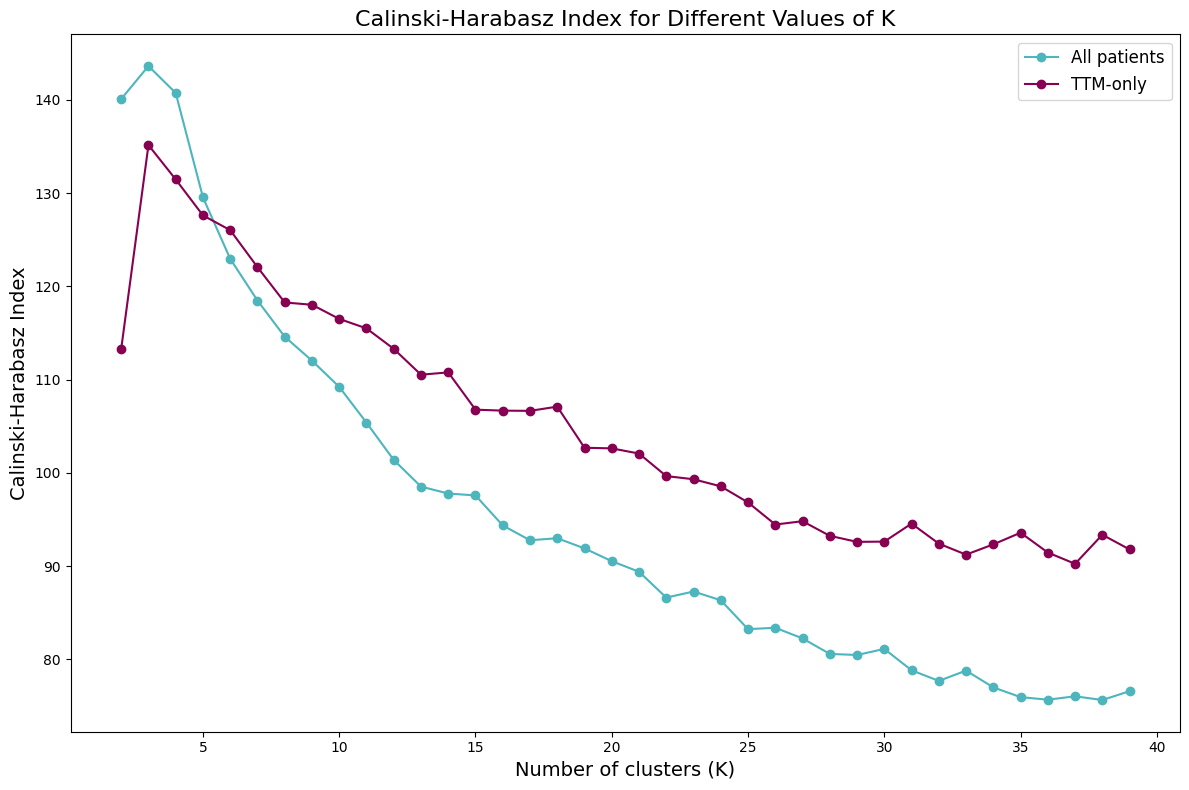

In [ ]:
# Evaluate Calinski–Harabasz index
ch_scores_all = {key: [] for key in dataframes_clustering.keys()}

for name, data in dataframes_clustering.items():
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=2023, n_init=20)
        labels = kmeans.fit_predict(data)
        ch = calinski_harabasz_score(data, labels)
        ch_scores_all[name].append(ch)

# Plot
plt.figure(figsize=(12, 8))
for i, (name, scores) in enumerate(ch_scores_all.items()):
    color = list(KI_COLORS.values())[i % len(KI_COLORS)]
    plt.plot(k_values, scores, marker='o', label=name, color=color)

plt.xlabel('Number of clusters (K)', fontsize=14)
plt.ylabel('Calinski-Harabasz Index', fontsize=14)
plt.title('Calinski-Harabasz Index for Different Values of K', fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("graphics/calinski_scores_transparent.svg", format="svg", transparent=True)
plt.savefig("graphics/calinski_scores_white.svg", format="svg", transparent=False)
plt.show()


### Summary of Clustering Evaluation

To explore potential patient subgroups, clustering quality was evaluated using two internal validation metrics: the **Silhouette Score** and the **Calinski–Harabasz Index (CHI)**. Analyses were performed both on the **full dataset (all patients)** and on the **subset excluding “No TTM” patients (TTM-only)**.

---

#### Key Insights

1. **Silhouette Score**  
   - For **all patients**, silhouette scores steadily increase with higher cluster counts, reaching ≈ **0.34 at k = 29–36**.  
     → Indicates *moderate clustering structure*, though not strongly distinct.  
   - For **TTM-only**, silhouette scores are consistently higher, peaking at ≈ **0.39 at k ≈ 23–25**.  
     → Suggests that excluding “No TTM” patients produces *cleaner and more distinct clusters*.  

2. **Calinski–Harabasz Index (CHI)**  
   - For both **all patients** and **TTM-only**, CHI values **peak at k = 3–4** before gradually declining.  
     → This points to the presence of a few broad clusters in the data.  
   - The TTM-only dataset maintains higher CHI values at larger k, again suggesting more stable clustering structure when No TTM patients are excluded.  

3. **Interpretation**  
   - The results highlight a **dual perspective**:  
     - **Broad clustering structure** can be captured with **3–4 clusters**, likely representing the main patient groups.  
     - **Finer subgroups** can be revealed with **20–30 clusters**, particularly in the TTM-only subset.  
   - This indicates that patient heterogeneity is better expressed when focusing on those who underwent TTM, while inclusion of No TTM patients introduces noise.  

---

#### Conclusion
Clustering reveals both **global patient groupings (3–4 clusters)** and **subtypes (20–30 clusters)**, with clearer separation in the TTM-only population. This suggests that treatment-related stratification plays a significant role in identifying meaningful patient subgroups.


### 2.3 Visualization of Clusters  

To better understand the identified clusters, we visualize the results in both **3D** and **2D** spaces using **Principal Component Analysis (PCA)** for dimensionality reduction. This visualization helps illustrate the separation and distribution of clusters in a simplified manner, making it easier to interpret the clustering results.

---

#### **3D Visualization**  

We reduce the data to **3 components** using PCA and apply **K-Means clustering** with **4 and 10 clusters**. Each cluster is represented by different colors, with centroids highlighted in red for clear visibility.

- **4 clusters**: Highlights broad groupings of the data.  
- **20 clusters**: Provides a more detailed view of smaller subgroups.  

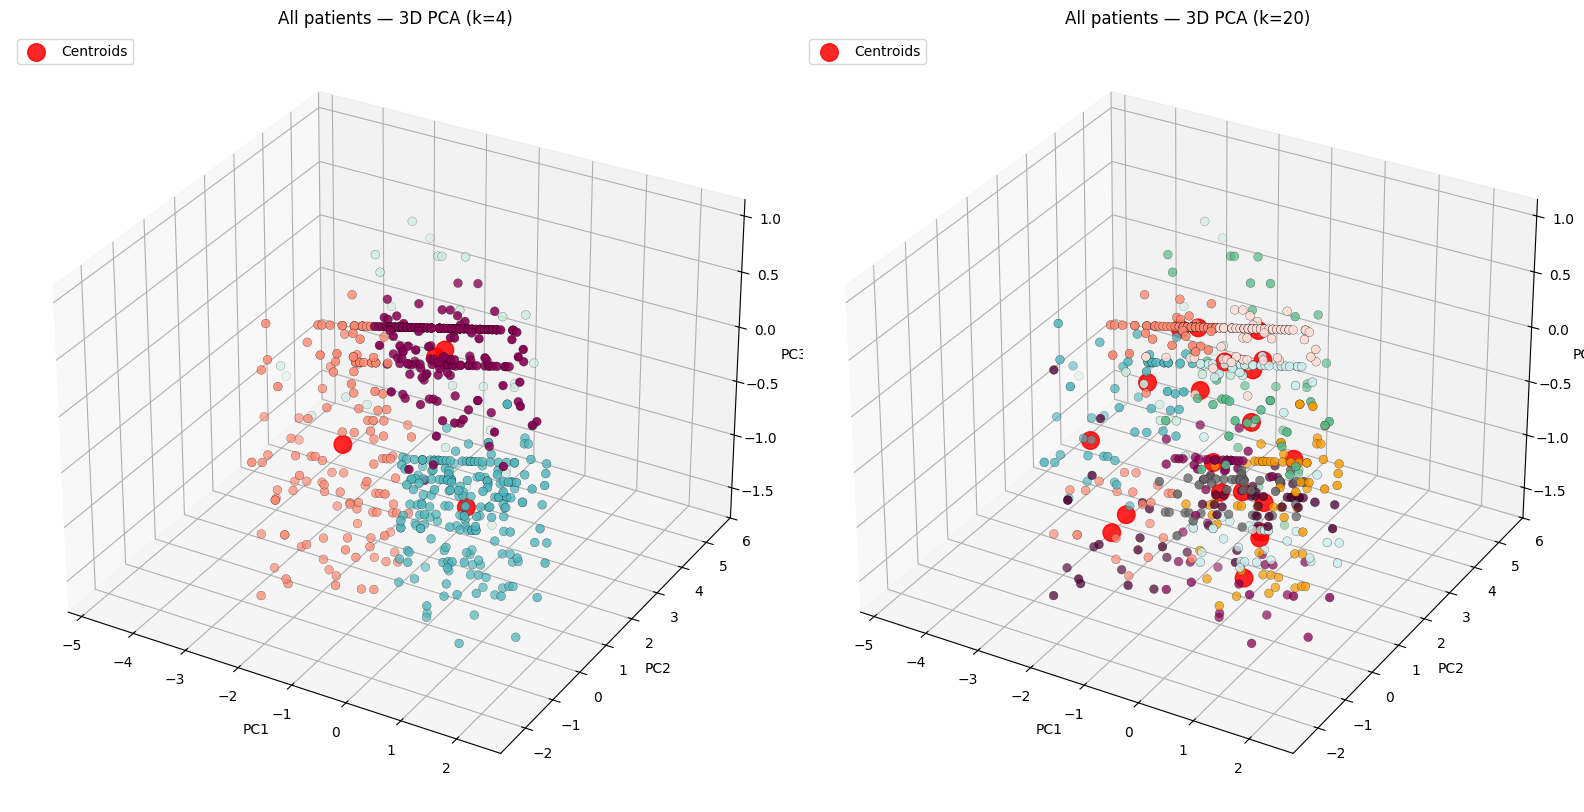

In [ ]:
# --- choose which prepared dataset to visualize ---
# (use "All patients" or "TTM-only" depending on what you prepared earlier)
DS_NAME = "All patients"   # or "TTM-only"

X = dataframes_clustering[DS_NAME].values  # should already exclude hospitals & (optionally) No TTM

# --- KI color palette (cycled if clusters > len(colors)) ---
KI_PALETTE = [
    "#4DB5BC",  # Blue
    "#870052",  # Plum
    "#FF876F",  # Orange
    "#C7ECDC",  # Light Green
    "#F59A00",  # Dark Yellow
    "#4F0433",  # Dark Plum
    "#FFDDD6",  # Light Orange
    "#666666",  # Grey
    "#CCEDED",  # Light Blue
    "#54B986",  # Green
]

def label_colors(labels):
    return [KI_PALETTE[i % len(KI_PALETTE)] for i in labels]

# =========================
# 3D PCA + KMeans (k=4,20)
# =========================
pca3 = PCA(n_components=3, random_state=2024)
X_3d = pca3.fit_transform(X)

# fit KMeans on the FULL space (not on PCA)
k4   = KMeans(n_clusters=4,  random_state=2024, n_init=20).fit(X)
k20  = KMeans(n_clusters=20, random_state=2024, n_init=20).fit(X)

labels4 = k4.labels_
labels20= k20.labels_

# project centroids into PCA space for visualization
cent4_3d  = pca3.transform(k4.cluster_centers_)
cent20_3d = pca3.transform(k20.cluster_centers_)

fig = plt.figure(figsize=(16, 8))

# left: k=4
ax1 = fig.add_subplot(121, projection="3d")
sc4 = ax1.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
                  c=label_colors(labels4), s=40, edgecolor="k", linewidth=0.2)
ax1.scatter(cent4_3d[:,0], cent4_3d[:,1], cent4_3d[:,2],
            c="red", s=160, alpha=0.85, label="Centroids")
ax1.set_title(f"{DS_NAME} — 3D PCA (k=4)")
ax1.set_xlabel("PC1"); ax1.set_ylabel("PC2"); ax1.set_zlabel("PC3")
ax1.legend(loc="upper left")

# right: k=20
ax2 = fig.add_subplot(122, projection="3d")
sc20 = ax2.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
                   c=label_colors(labels20), s=40, edgecolor="k", linewidth=0.2)
ax2.scatter(cent20_3d[:,0], cent20_3d[:,1], cent20_3d[:,2],
            c="red", s=160, alpha=0.85, label="Centroids")
ax2.set_title(f"{DS_NAME} — 3D PCA (k=20)")
ax2.set_xlabel("PC1"); ax2.set_ylabel("PC2"); ax2.set_zlabel("PC3")
ax2.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"graphics/{DS_NAME.replace(' ','_').lower()}_pca3_k4_k20.svg", format="svg", transparent=True)
plt.show()



#### **2D Visualization**
For simpler visualization, the data is reduced to 2 components using PCA, and the same K-Means clustering approach is applied for 4 and 10 clusters. This view offers a flat representation of the cluster separations.

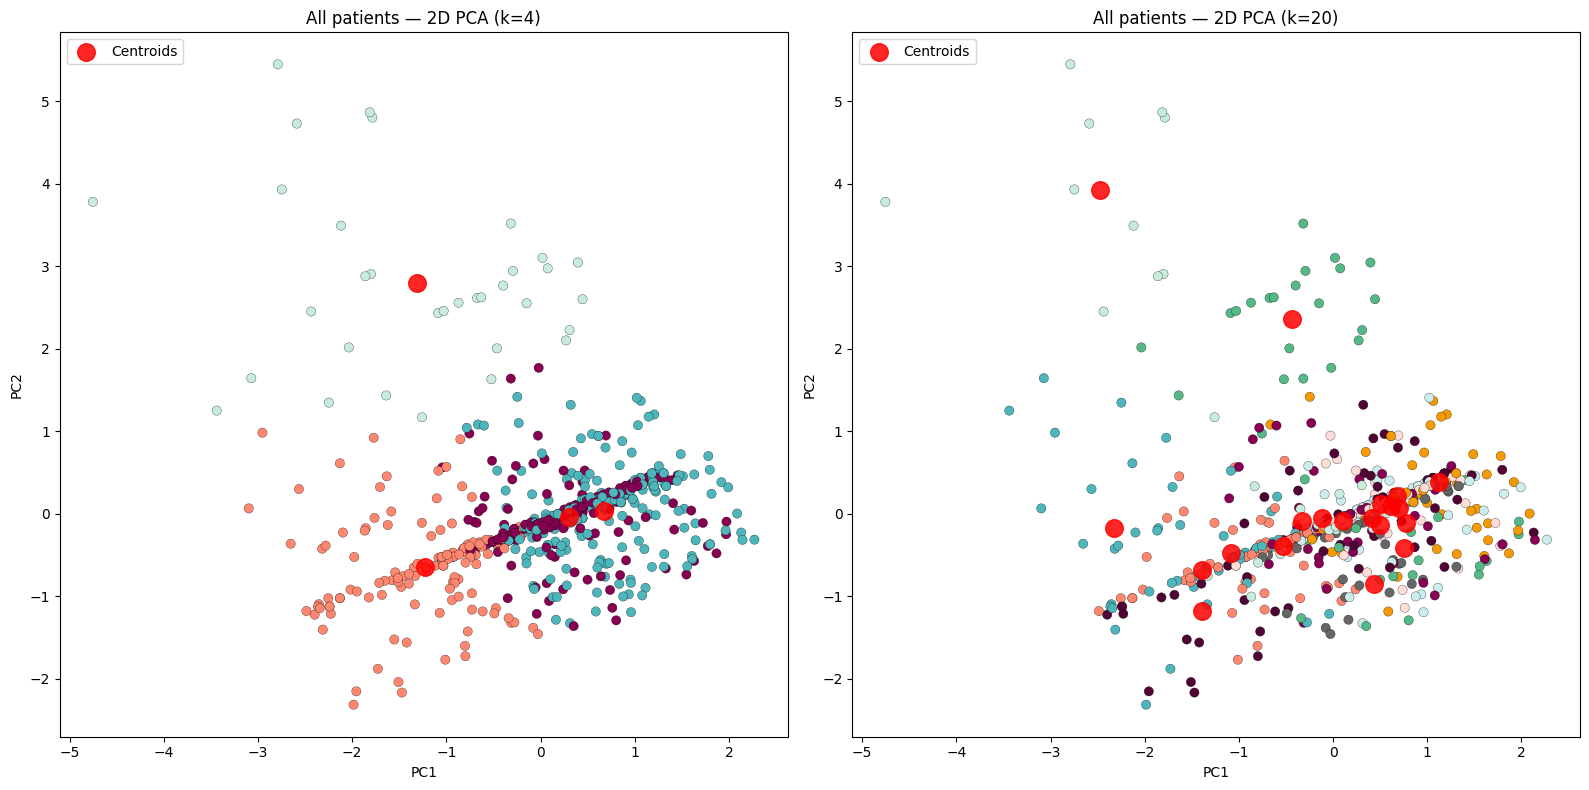

In [ ]:
# =========================
# 2D PCA + KMeans (k=4,20)
# =========================
pca2 = PCA(n_components=2, random_state=2024)
X_2d = pca2.fit_transform(X)

cent4_2d  = pca2.transform(k4.cluster_centers_)
cent20_2d = pca2.transform(k20.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# left: k=4
ax = axes[0]
ax.scatter(X_2d[:,0], X_2d[:,1], c=label_colors(labels4), s=45, edgecolor="k", linewidth=0.2)
ax.scatter(cent4_2d[:,0], cent4_2d[:,1], c="red", s=160, alpha=0.85, label="Centroids")
ax.set_title(f"{DS_NAME} — 2D PCA (k=4)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(loc="upper left")

# right: k=20
ax = axes[1]
ax.scatter(X_2d[:,0], X_2d[:,1], c=label_colors(labels20), s=45, edgecolor="k", linewidth=0.2)
ax.scatter(cent20_2d[:,0], cent20_2d[:,1], c="red", s=160, alpha=0.85, label="Centroids")
ax.set_title(f"{DS_NAME} — 2D PCA (k=20)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(loc="upper left")

plt.tight_layout()
plt.savefig(f"graphics/{DS_NAME.replace(' ','_').lower()}_pca2_k4_k20.svg", format="svg", transparent=True)
plt.show()

# (Optional) If you want the labels back for profiling:
# df_viz = dataframes_clustering[DS_NAME].copy()
# df_viz["cluster_k4"]  = labels4
# df_viz["cluster_k20"] = labels20
# display(df_viz.head())

### Perform the Clustering  

In this section, we apply the **K-Means clustering** to identify groups of patients with shared characteristics with the previously identified number of clusters. The clustering process aims to evaluate whether distinct subgroups exist that exhibit meaningful differences in their outcomes or responses to TTM protocols.  

We will **Analyze feature distributions** across the identified clusters to evaluate differences and similarities.  

This analysis helps us explore potential subpopulations that might benefit (or be harmed) by specific TTM strategies, laying the foundation for further predictive modeling and counterfactual analysis.  


In [ ]:
# ---------------------------
# 1) Prepare feature sets
# ---------------------------
df_base = df_full.copy()

hosp_cols = [c for c in df_base.columns if c.startswith("cats__hospital_")]
df_nohosp = df_base.drop(columns=hosp_cols, errors="ignore")

# sanity check: ensure nothing hospital-like remains
leftover_hosp = [c for c in df_nohosp.columns if c.startswith("cats__hospital_")]
print("Hospital columns present in clustering data:", leftover_hosp)

Hospital columns present in clustering data: []


In [8]:
# ========= 2) Build ALL-patients and TTM-only matrices (drop outcome for X) =========
X_all_df = df_nohosp.drop(columns=["outcome"], errors="ignore")
idx_all  = X_all_df.index

# TTM-only: exclude rows where No TTM == 1, then drop that column (it would be all-zero)
if "cats__ttm_No TTM" in X_all_df.columns:
    mask_ttm = X_all_df["cats__ttm_No TTM"] == 0
    X_ttm_df = X_all_df.loc[mask_ttm].drop(columns=["cats__ttm_No TTM"])
    idx_ttm  = X_ttm_df.index
else:
    X_ttm_df = X_all_df.copy()
    idx_ttm  = X_ttm_df.index

X_all = X_all_df.values.astype(float)
X_ttm = X_ttm_df.values.astype(float)

print("Shapes → ALL:", X_all.shape, " | TTM-only:", X_ttm.shape)

Shapes → ALL: (607, 14)  | TTM-only: (509, 13)


In [9]:
# ========= 3) Helper: fit KMeans and score =========
def fit_kmeans_labels(X, k, seed=2024, n_init=20):
    km = KMeans(n_clusters=k, random_state=seed, n_init=n_init)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    ch  = calinski_harabasz_score(X, labels)
    return labels, sil, ch


In [10]:
# ========= 4) Fit k=4 and k=20 on BOTH datasets =========
labels_all_k4,  sil_all_k4,  ch_all_k4  = fit_kmeans_labels(X_all,  4)
labels_all_k20, sil_all_k20, ch_all_k20 = fit_kmeans_labels(X_all, 20)

labels_ttm_k4,  sil_ttm_k4,  ch_ttm_k4  = fit_kmeans_labels(X_ttm,  4)
labels_ttm_k20, sil_ttm_k20, ch_ttm_k20 = fit_kmeans_labels(X_ttm, 20)

print(f"[ALL] k=4  → silhouette={sil_all_k4:.3f}  CH={ch_all_k4:.1f}")
print(f"[ALL] k=20 → silhouette={sil_all_k20:.3f} CH={ch_all_k20:.1f}")
print(f"[TTM] k=4  → silhouette={sil_ttm_k4:.3f}  CH={ch_ttm_k4:.1f}")
print(f"[TTM] k=20 → silhouette={sil_ttm_k20:.3f} CH={ch_ttm_k20:.1f}")



[ALL] k=4  → silhouette=0.207  CH=140.8
[ALL] k=20 → silhouette=0.315 CH=88.9
[TTM] k=4  → silhouette=0.230  CH=131.4
[TTM] k=20 → silhouette=0.346 CH=101.5


In [11]:
# ========= 5) Write labels back (to a hospital-free working frame) =========
df_clusters = df_nohosp.copy()

# init columns as NA; fill per index
for col in ["km_all_k4", "km_all_k20", "km_ttm_k4", "km_ttm_k20"]:
    df_clusters[col] = np.nan

df_clusters.loc[idx_all, "km_all_k4"]  = labels_all_k4
df_clusters.loc[idx_all, "km_all_k20"] = labels_all_k20
df_clusters.loc[idx_ttm, "km_ttm_k4"]  = labels_ttm_k4
df_clusters.loc[idx_ttm, "km_ttm_k20"] = labels_ttm_k20

# nicer dtype for display
for col in ["km_all_k4", "km_all_k20", "km_ttm_k4", "km_ttm_k20"]:
    df_clusters[col] = df_clusters[col].astype("Int64")

df_clusters.head()

,rosc__rosc,nums__age,cats__sex_Female,cats__sex_Male,cats__sex_nan,cats__ohca_False,cats__ohca_True,cats__ohca_Unknown,cats__shockable_rhythm_False,cats__shockable_rhythm_True,cats__shockable_rhythm_Unknown,cats__ttm_33.0,cats__ttm_36.0,cats__ttm_No TTM,outcome,km_all_k4,km_all_k20,km_ttm_k4,km_ttm_k20
0,-0.489125,1.409359,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0,0,14,<NA>,<NA>
1,-0.141507,-1.449509,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,2,0,3,16
2,-0.489125,1.864179,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,4,0,11
3,-0.141507,-0.409920,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1,1,19,1,17
4,0.553729,-1.644431,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1,2,0,<NA>,<NA>


In [13]:
dfc = df_clusters.copy()

LABEL_COLS = ["km_all_k4", "km_all_k20", "km_ttm_k4", "km_ttm_k20"]

summary_rows = []
for col in LABEL_COLS:
    if col not in dfc.columns:
        print(f"Warning: {col} not found; skipping.")
        continue

    # Drop rows without a label for this run (e.g., TTM-only columns will be NaN for No-TTM rows)
    m = dfc[col].notna()
    df_sub = dfc.loc[m, [col]].copy()
    df_sub[col] = df_sub[col].astype(int)

    counts = df_sub[col].value_counts().sort_index()
    props  = (counts / counts.sum()).round(3)

    # Print per-run summary
    print(f"\n=== Cluster size summary for {col} ===")
    display(pd.DataFrame({"count": counts, "proportion": props}))

    # Collect into a long table for all runs
    for k_label, cnt in counts.items():
        summary_rows.append({"run": col, "cluster": int(k_label), "count": int(cnt), "proportion": float((cnt / counts.sum()))})

# One combined table
summary_df = pd.DataFrame(summary_rows).sort_values(["run", "cluster"]).reset_index(drop=True)


=== Cluster size summary for km_all_k4 ===


,count,proportion
km_all_k4,,
0,218,0.359
1,217,0.357
2,139,0.229
3,33,0.054



=== Cluster size summary for km_all_k20 ===


,count,proportion
km_all_k20,,
0,37,0.061
1,33,0.054
2,72,0.119
3,10,0.016
4,31,0.051
5,39,0.064
6,75,0.124
7,27,0.044
8,33,0.054



=== Cluster size summary for km_ttm_k4 ===


,count,proportion
km_ttm_k4,,
0,172,0.338
1,199,0.391
2,29,0.057
3,109,0.214



=== Cluster size summary for km_ttm_k20 ===


,count,proportion
km_ttm_k20,,
0,62,0.122
1,34,0.067
2,18,0.035
3,14,0.028
4,42,0.083
5,18,0.035
6,21,0.041
7,7,0.014
8,22,0.043


#### 2.2 Cluster Analysis

We will now analyze the clusters by examining the distribution of features within each cluster. This analysis will provide insights into the characteristics that define each group.


In [14]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, kruskal
from sklearn.metrics import adjusted_rand_score

def cramer_v(ct):
    # Cramer's V (effect size) for a contingency table
    chi2, p, dof, exp = chi2_contingency(ct, correction=False)
    n = ct.to_numpy().sum()
    r, k = ct.shape
    return np.sqrt((chi2 / n) / (min(r-1, k-1))), p

def analyze_run(df_clusters: pd.DataFrame, label_col: str):
    """
    df_clusters has:
      - OHE features (cats__ttm_*, cats__shockable_rhythm_*, etc.)
      - numeric z-scored features (nums__age, rosc__rosc)
      - outcome (0/1)
      - label_col: one of km_all_k4, km_all_k20, km_ttm_k4, km_ttm_k20
    """
    assert label_col in df_clusters.columns, f"{label_col} not found"
    df = df_clusters.copy()
    df = df[df[label_col].notna()].copy()
    df[label_col] = df[label_col].astype(int)

    # ---------- sizes ----------
    sizes = (df[label_col].value_counts()
             .sort_index()
             .rename("count")
             .to_frame())
    sizes["proportion"] = (sizes["count"] / sizes["count"].sum()).round(3)

    # ---------- outcome distribution ----------
    if "outcome" in df.columns:
        outcome_ct = pd.crosstab(df[label_col], df["outcome"])
        outcome_pct = (outcome_ct.div(outcome_ct.sum(axis=1), axis=0) * 100).round(1)
        # chi-square for outcome ~ cluster
        chi2, p, dof, _ = chi2_contingency(outcome_ct, correction=False)
        outcome_cramerv, outcome_p = cramer_v(outcome_ct)
    else:
        outcome_ct = pd.DataFrame(); outcome_pct = pd.DataFrame()
        chi2 = p = dof = outcome_cramerv = outcome_p = np.nan

    # ---------- TTM composition (prevalence by cluster) ----------
    ttm_cols = [c for c in ["cats__ttm_33.0","cats__ttm_36.0","cats__ttm_No TTM"] if c in df.columns]
    if ttm_cols:
        # prevalence ≈ mean of 0/1 columns
        ttm_prev = df.groupby(label_col)[ttm_cols].mean().mul(100).round(1)
        # long format for a χ² test of *categories* (choose argmax category per row)
        # If No TTM absent (TTM-only), we still test 33 vs 36 distribution across clusters
        cats = []
        for col in ttm_cols:
            # build categorical label from argmax across available TTM one-hots
            pass
        # robust categorical derivation:
        ttm_cat = pd.Series(index=df.index, dtype="object")
        for i in df.index:
            vals = {c: df.at[i, c] for c in ttm_cols}
            # pick the category with value 1; if ties/none, choose max
            label = max(vals, key=vals.get)
            ttm_cat.at[i] = label
        ttm_ct = pd.crosstab(df[label_col], ttm_cat)
        ttm_cramerv, ttm_p = cramer_v(ttm_ct)
    else:
        ttm_prev = pd.DataFrame(); ttm_ct = pd.DataFrame()
        ttm_cramerv = ttm_p = np.nan

    # ---------- numeric features across clusters ----------
    num_cols = [c for c in ["nums__age","rosc__rosc"] if c in df.columns]
    num_summary = df.groupby(label_col)[num_cols].agg(["mean","std","median","count"]).round(3) if num_cols else pd.DataFrame()
    # Kruskal–Wallis across clusters (non-parametric)
    kw_results = {}
    for col in num_cols:
        groups = [g[col].values for _, g in df.groupby(label_col)]
        if len(groups) >= 2:
            kw = kruskal(*groups)
            kw_results[col] = {"H": float(kw.statistic), "p": float(kw.pvalue)}
    kw_df = pd.DataFrame(kw_results).T if kw_results else pd.DataFrame()

    results = {
        "sizes": sizes,
        "outcome_counts": outcome_ct,
        "outcome_pct": outcome_pct,
        "outcome_chi2": {"chi2": float(chi2), "dof": int(dof), "p": float(p)},
        "outcome_cramerV": {"V": float(outcome_cramerv), "p": float(outcome_p)},
        "ttm_prevalence_pct": ttm_prev,
        "ttm_contingency": ttm_ct,
        "ttm_cramerV": {"V": float(ttm_cramerv), "p": float(ttm_p)},
        "numeric_summary": num_summary,
        "kruskal_numeric": kw_df,
    }
    return results


In [15]:
runs = ["km_all_k4", "km_all_k20", "km_ttm_k4", "km_ttm_k20"]
all_results = {}

for r in runs:
    print(f"\n========== Analysis for {r} ==========")
    res = analyze_run(df_clusters, r)
    all_results[r] = res

    print("\nCluster sizes:")
    display(res["sizes"])

    if not res["outcome_pct"].empty:
        print("\nOutcome distribution (%):")
        display(res["outcome_pct"])
        print(f"Outcome χ² p={res['outcome_chi2']['p']:.4f}, Cramér's V={res['outcome_cramerV']['V']:.3f}")

    if not res["ttm_prevalence_pct"].empty:
        print("\nTTM prevalence per cluster (%):")
        display(res["ttm_prevalence_pct"])
        if not res["ttm_contingency"].empty:
            print(f"TTM χ² p={res['ttm_cramerV']['p']:.4f}, Cramér's V={res['ttm_cramerV']['V']:.3f}")

    if not res["numeric_summary"].empty:
        print("\nNumeric summaries (z-space for age/rosc):")
        display(res["numeric_summary"])
        if not res["kruskal_numeric"].empty:
            print("\nKruskal–Wallis (across clusters):")
            display(res["kruskal_numeric"])



========== Analysis for km_all_k4 ==========

Cluster sizes:


,count,proportion
km_all_k4,,
0,218,0.359
1,217,0.357
2,139,0.229
3,33,0.054



Outcome distribution (%):


outcome,0,1
km_all_k4,,
0,81.7,18.3
1,46.1,53.9
2,53.2,46.8
3,90.9,9.1


Outcome χ² p=0.0000, Cramér's V=0.353

TTM prevalence per cluster (%):


...

,cats__ttm_33.0,cats__ttm_36.0,cats__ttm_No TTM
km_ttm_k20,,,
0,98.4,1.6,0.0
1,91.2,8.8,0.0
2,100.0,0.0,0.0
3,100.0,0.0,0.0
4,97.6,2.4,0.0
5,94.4,5.6,0.0
6,100.0,0.0,0.0
7,100.0,0.0,0.0
8,0.0,100.0,0.0


TTM χ² p=0.0000, Cramér's V=0.889

Numeric summaries (z-space for age/rosc):


nums__age                     rosc__rosc                    
                mean    std median count       mean    std median count
km_ttm_k20                                                             
0              0.728  0.367  0.630    62     -0.211  0.331 -0.142    62
1              0.559  0.673  0.532    34     -0.399  0.555 -0.142    34
2              0.630  0.526  0.565    18      2.288  0.563  2.639    18
3             -1.528  0.498 -1.482    14     -0.092  0.365 -0.142    14
4             -0.147  0.415 -0.085    42     -0.363  0.546 -0.142    42
5              1.045  0.254  1.020    18     -0.288  0.330 -0.142    18
6             -1.326  0.390 -1.190    21     -0.218  0.443 -0.142    21
7             -0.688  1.081 -0.475     7      5.122  0.658  5.142     7
8             -0.067  0.578  0.012    22     -0.063  0.282 -0.142    22
9              0.051  0.823 -0.118    10     -0.142  0.000 -0.142    10
10             0.072  0.357  0.077    24     -0.173  0.320 -0.142    24
11             1.125  0.411  1.149    32     -0.194  0.528 -0.142    32
12            -0.309  0.280 -0.345    66     -0.162  0.313 -0.142    66
13             0.760  0.555  0.792    36     -0.169  0.488 -0.142    36
14             0.446  0.574  0.305    17     -0.142  0.000 -0.142    17
15             0.313  0.840  0.402    16     -0.302  0.727 -0.142    16
16            -1.218  0.578 -1.060    25     -0.161  0.506 -0.142    25
17             0.411  0.704  0.240    19     -0.577  0.539 -0.489    19
18            -1.162  0.570 -1.060     7      2.729  0.569  2.639     7
19            -2.062  0.519 -2.099    19     -0.251  0.799 -0.281    19


Kruskal–Wallis (across clusters):


,H,p
nums__age,362.795241,2.304042e-65
rosc__rosc,135.148163,1.537562e-19


In [21]:
# ========== KI colors ==========
KI_COLORS = {
    "dark_plum":   "#4F0433",
    "orange":      "#FF876F",
    "plum":        "#870052",
    "light_orange":"#FFDDD6",
    "blue":        "#4DB5BC",
    "light_blue":  "#CCEBED",
    "green":       "#54B986",
    "light_green": "#C7ECDC",
    "yellow":      "#FFC66D",
    "light_yellow":"#FFE7C2",
    "grey":        "#666666",
}

# Palettes for specific variables (consistent across runs)
PAL_OUTCOME = [KI_COLORS["blue"], KI_COLORS["plum"]]  # Good, Poor (we’ll relabel 0/1)
PAL_TTM     = [KI_COLORS["green"], KI_COLORS["light_green"], KI_COLORS["orange"]]  # 33.0, 36.0, No TTM
PAL_OHCA    = [KI_COLORS["green"], KI_COLORS["orange"], KI_COLORS["yellow"]]       # False, True, Unknown
PAL_RHYTHM  = [KI_COLORS["orange"], KI_COLORS["green"], KI_COLORS["light_orange"]] # False, True, Unknown
PAL_SEX     = [KI_COLORS["blue"], KI_COLORS["plum"], KI_COLORS["light_orange"]]    # Female, Male, Unknown

def _stacked_bar(ax, df_pct, colors, title, ylabel="Percentage", annotate=True):
    use_colors = colors[:df_pct.shape[1]]
    df_pct.plot(kind="bar", stacked=True, ax=ax, color=use_colors, edgecolor="black")
    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Cluster", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_ylim(0, 100)
    ax.set_yticks(range(0, 101, 10))
    ax.legend(title="", fontsize=11, loc="upper right")
    if annotate:
        for p in ax.patches:
            h = p.get_height()
            if h >= 10:
                ax.annotate(f"{h:.0f}%", (p.get_x()+p.get_width()/2, p.get_y()+h/2),
                            ha="center", va="center", fontsize=10, color="black")

def _counts_to_pct(ct):
    return ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

def _build_cat_from_onehots(df, cols, prefix):
    present = [c for c in cols if c in df.columns]
    if not present:
        return pd.Series(index=df.index, dtype="object")
    labels = []
    for i, row in df[present].iterrows():
        col = row.idxmax()
        labels.append(col.replace(prefix, ""))
    return pd.Series(labels, index=df.index)

def plot_cluster_summary(df_clusters, label_col, raw_df=None, save_path=None):
    """
    2-column, larger dashboard with:
      Row 1: Outcome %, TTM %
      Row 2: OHCA %, Rhythm %
      Row 3: Sex %, Boxplots for raw Age/ROSC (falls back to z if raw not available)

    Parameters
    ----------
    df_clusters : pd.DataFrame
        Hospital-free frame containing OHE features, 'outcome', and the cluster label columns.
    label_col : str
        One of {"km_all_k4","km_all_k20","km_ttm_k4","km_ttm_k20"}.
    raw_df : pd.DataFrame or None
        Optional original (raw) dataframe that has 'age' and 'rosc' (real units).
        If provided and aligned by index, raw values will be used for boxplots.
        If not provided / missing, falls back to 'age'/'rosc' if present in df_clusters,
        otherwise to 'nums__age'/'rosc__rosc' (z-space).
    save_path : str or None
        If provided, saves the SVG figure at this path.
    """
    assert label_col in df_clusters.columns, f"{label_col} not found in df_clusters"
    df = df_clusters[df_clusters[label_col].notna()].copy()
    df[label_col] = df[label_col].astype(int)

    # Optionally join raw age/rosc
    age_col, rosc_col = None, None
    if raw_df is not None:
        # align on index
        raw_join = raw_df.loc[df.index]
        if "age" in raw_join.columns:
            df["__raw_age"] = raw_join["age"]
            age_col = "__raw_age"
        if "rosc" in raw_join.columns:
            df["__raw_rosc"] = raw_join["rosc"]
            rosc_col = "__raw_rosc"

    # If raw not found, try in df_clusters
    if age_col is None:
        if "age" in df.columns:
            age_col = "age"
        elif "nums__age" in df.columns:
            age_col = "nums__age"   # fallback (z)
    if rosc_col is None:
        if "rosc" in df.columns:
            rosc_col = "rosc"
        elif "rosc__rosc" in df.columns:
            rosc_col = "rosc__rosc" # fallback (z)

    # --- Outcome % ---
    if "outcome" in df.columns:
        out_map = {0: "Poor", 1: "Good"}
        ct_out = pd.crosstab(df[label_col], df["outcome"]).sort_index(axis=0)
        pct_out = _counts_to_pct(ct_out).rename(columns=out_map).reindex(columns=["Good","Poor"], fill_value=0)
    else:
        pct_out = pd.DataFrame()

    # --- TTM % (from one-hots) ---
    ttm_cols = ["cats__ttm_33.0","cats__ttm_36.0","cats__ttm_No TTM"]
    ttm_cat = _build_cat_from_onehots(df, ttm_cols, "cats__ttm_")
    ct_ttm = pd.crosstab(df[label_col], ttm_cat).sort_index(axis=0)
    pct_ttm = _counts_to_pct(ct_ttm)
    pct_ttm = pct_ttm.reindex(columns=[c for c in ["33.0","36.0","No TTM"] if c in pct_ttm.columns], fill_value=0)

    # --- OHCA % ---
    oh_cols = ["cats__ohca_False","cats__ohca_True","cats__ohca_Unknown"]
    oh_cat = _build_cat_from_onehots(df, oh_cols, "cats__ohca_")
    ct_oh = pd.crosstab(df[label_col], oh_cat).sort_index(axis=0)
    pct_oh = _counts_to_pct(ct_oh).reindex(columns=[c for c in ["False","True","Unknown"] if c in ct_oh.columns], fill_value=0)

    # --- Rhythm % ---
    rh_cols = ["cats__shockable_rhythm_False","cats__shockable_rhythm_True","cats__shockable_rhythm_Unknown"]
    rh_cat = _build_cat_from_onehots(df, rh_cols, "cats__shockable_rhythm_")
    ct_rh = pd.crosstab(df[label_col], rh_cat).sort_index(axis=0)
    pct_rh = _counts_to_pct(ct_rh).reindex(columns=[c for c in ["False","True","Unknown"] if c in ct_rh.columns], fill_value=0)

    # --- Sex % ---
    sx_cols = ["cats__sex_Female","cats__sex_Male","cats__sex_nan"]
    sx_cat = _build_cat_from_onehots(df, sx_cols, "cats__sex_").replace({"nan":"Unknown"})
    ct_sx = pd.crosstab(df[label_col], sx_cat).sort_index(axis=0)
    pct_sx = _counts_to_pct(ct_sx).reindex(columns=[c for c in ["Female","Male","Unknown"] if c in ct_sx.columns], fill_value=0)

    # --- Figure: 3 rows × 2 cols (bigger plots) ---
    fig, axes = plt.subplots(3, 2, figsize=(16, 18))
    axes = axes.flatten()

    # Row 1
    if not pct_out.empty:
        _stacked_bar(axes[0], pct_out, PAL_OUTCOME, f"Outcome (%) — {label_col}")
    else:
        axes[0].axis("off"); axes[0].set_title("Outcome not available")
    _stacked_bar(axes[1], pct_ttm, PAL_TTM, f"TTM (%) — {label_col}")

    # Row 2
    _stacked_bar(axes[2], pct_oh, PAL_OHCA, f"OHCA (%) — {label_col}")
    _stacked_bar(axes[3], pct_rh, PAL_RHYTHM, f"Shockable rhythm (%) — {label_col}")

    # Row 3
    _stacked_bar(axes[4], pct_sx, PAL_SEX, f"Sex (%) — {label_col}")

    # Boxplots for raw (or fallback) age/rosc
    ax = axes[5]
    num_cols = [c for c in [age_col, rosc_col] if c is not None]
    if num_cols:
        # Melt for seaborn boxplot
        melt_df = df[[label_col] + num_cols].melt(id_vars=label_col, var_name="feature", value_name="value")
        # nicer labels
        rename_map = {
            "age": "Age (years)", "rosc": "ROSC (minutes)",
            "nums__age": "Age (z)", "rosc__rosc": "ROSC (z)",
            "__raw_age": "Age (years)", "__raw_rosc": "ROSC (minutes)"
        }
        melt_df["feature"] = melt_df["feature"].replace(rename_map)
        sns.boxplot(
            x=label_col, y="value", hue="feature", data=melt_df, ax=ax,
            palette=[KI_COLORS["light_blue"], KI_COLORS["orange"]][:len(num_cols)],
            showcaps=True, fliersize=2
        )
        ax.set_title(f"Numeric distributions — {label_col}", fontsize=16)
        ax.set_xlabel("Cluster", fontsize=14); ax.set_ylabel("", fontsize=14)
        ax.legend(title="", fontsize=11, loc="best")
    else:
        ax.axis("off"); ax.set_title("Numeric features not available")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, format="svg", transparent=True)
    plt.show()

    return {
        "outcome_pct": pct_out,
        "ttm_pct": pct_ttm,
        "ohca_pct": pct_oh,
        "rhythm_pct": pct_rh,
        "sex_pct": pct_sx
    }


4 Clusters - All TTM protocols included


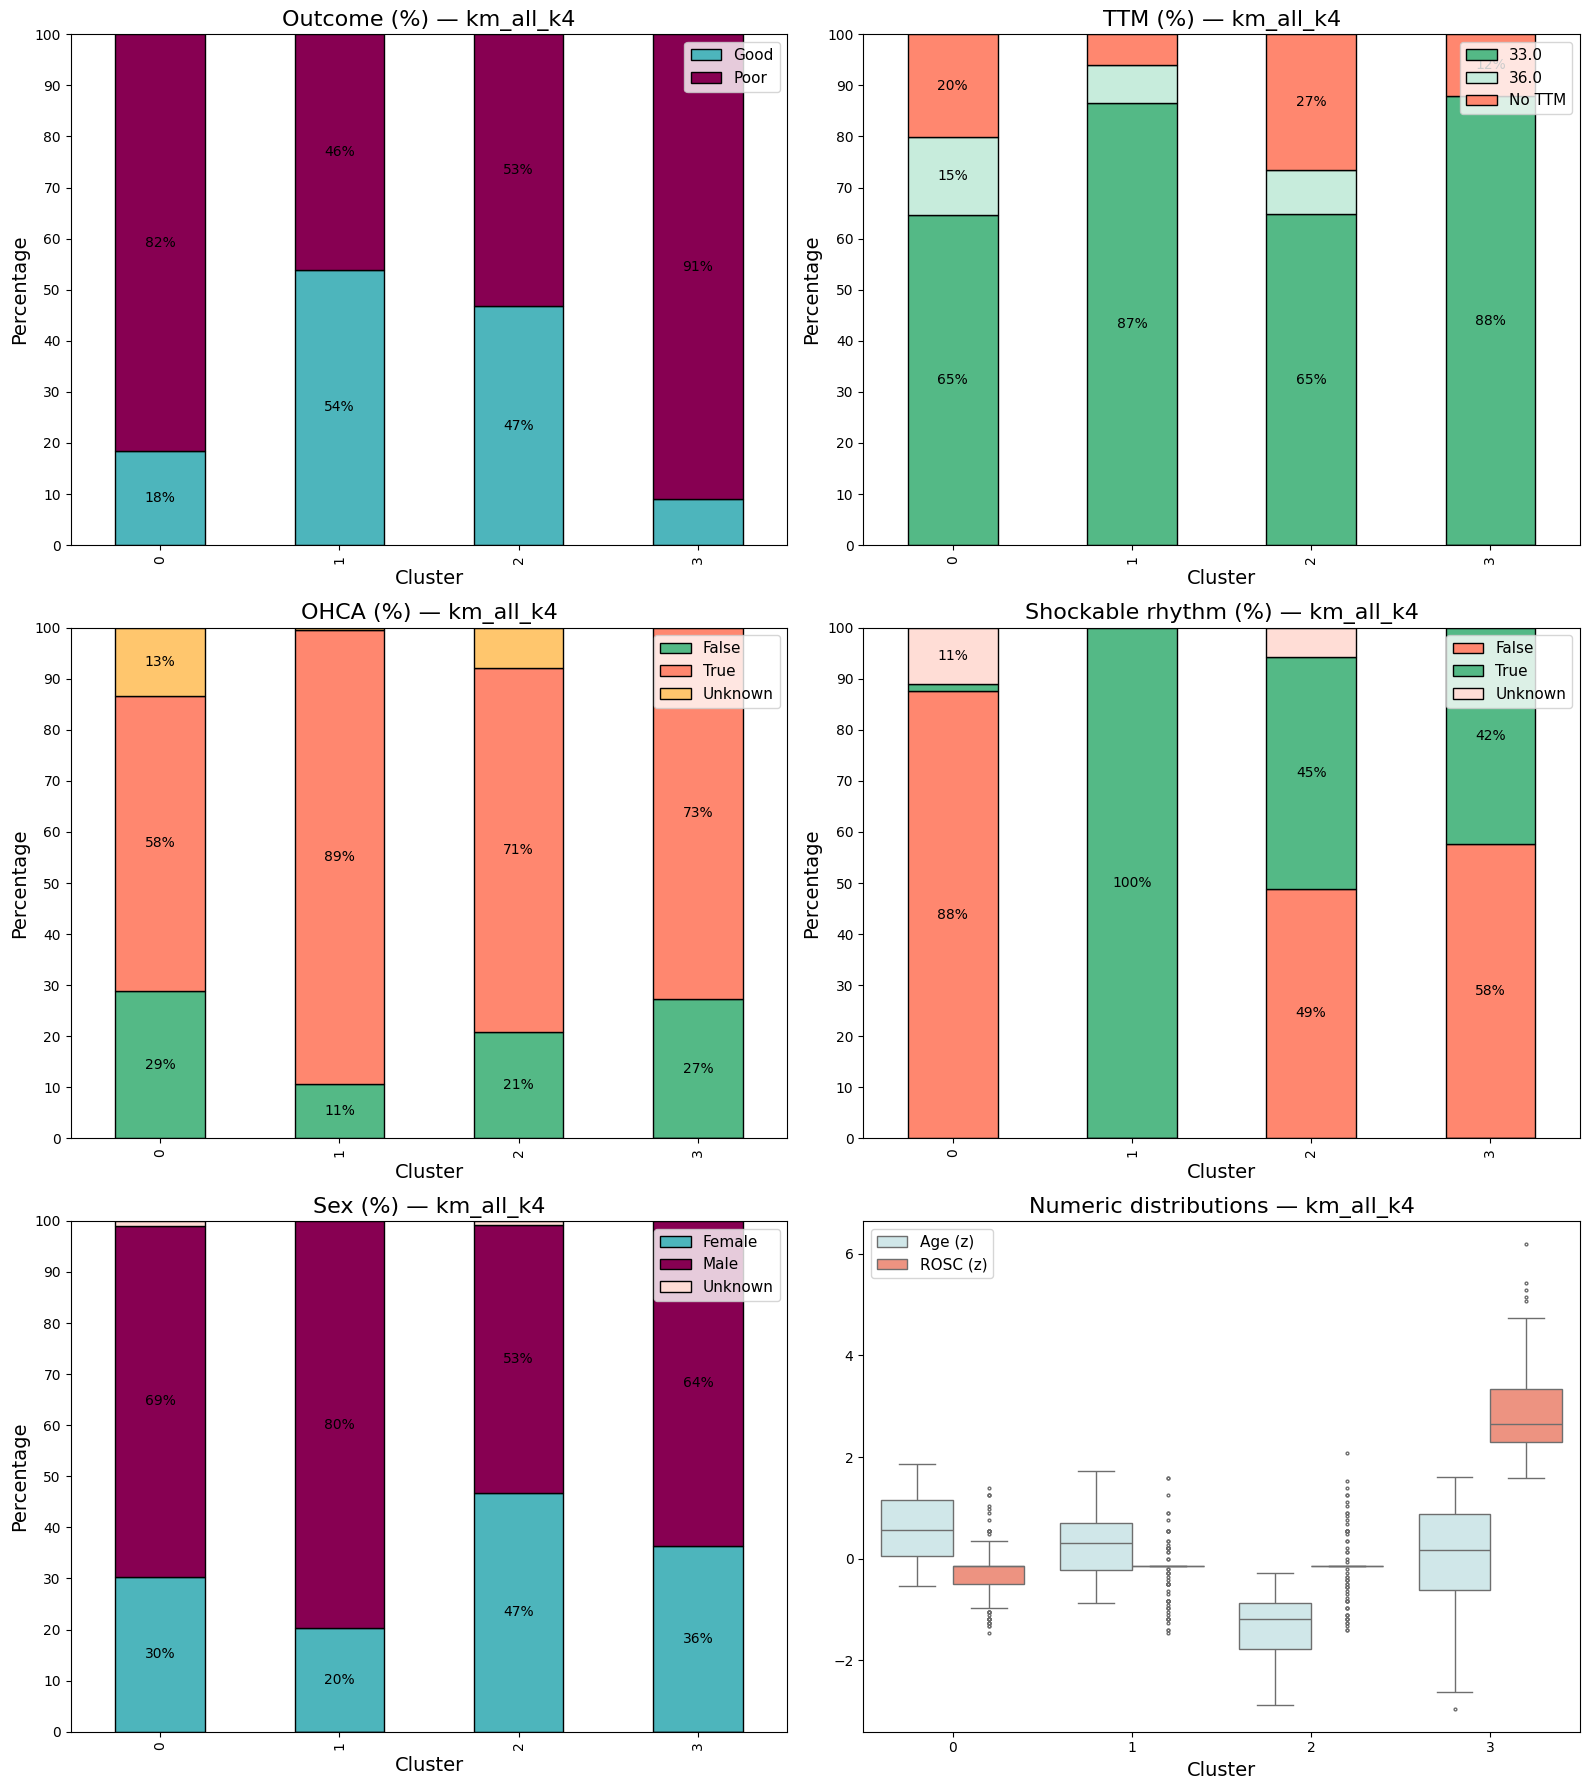

20 Clusters - All TTM protocols included


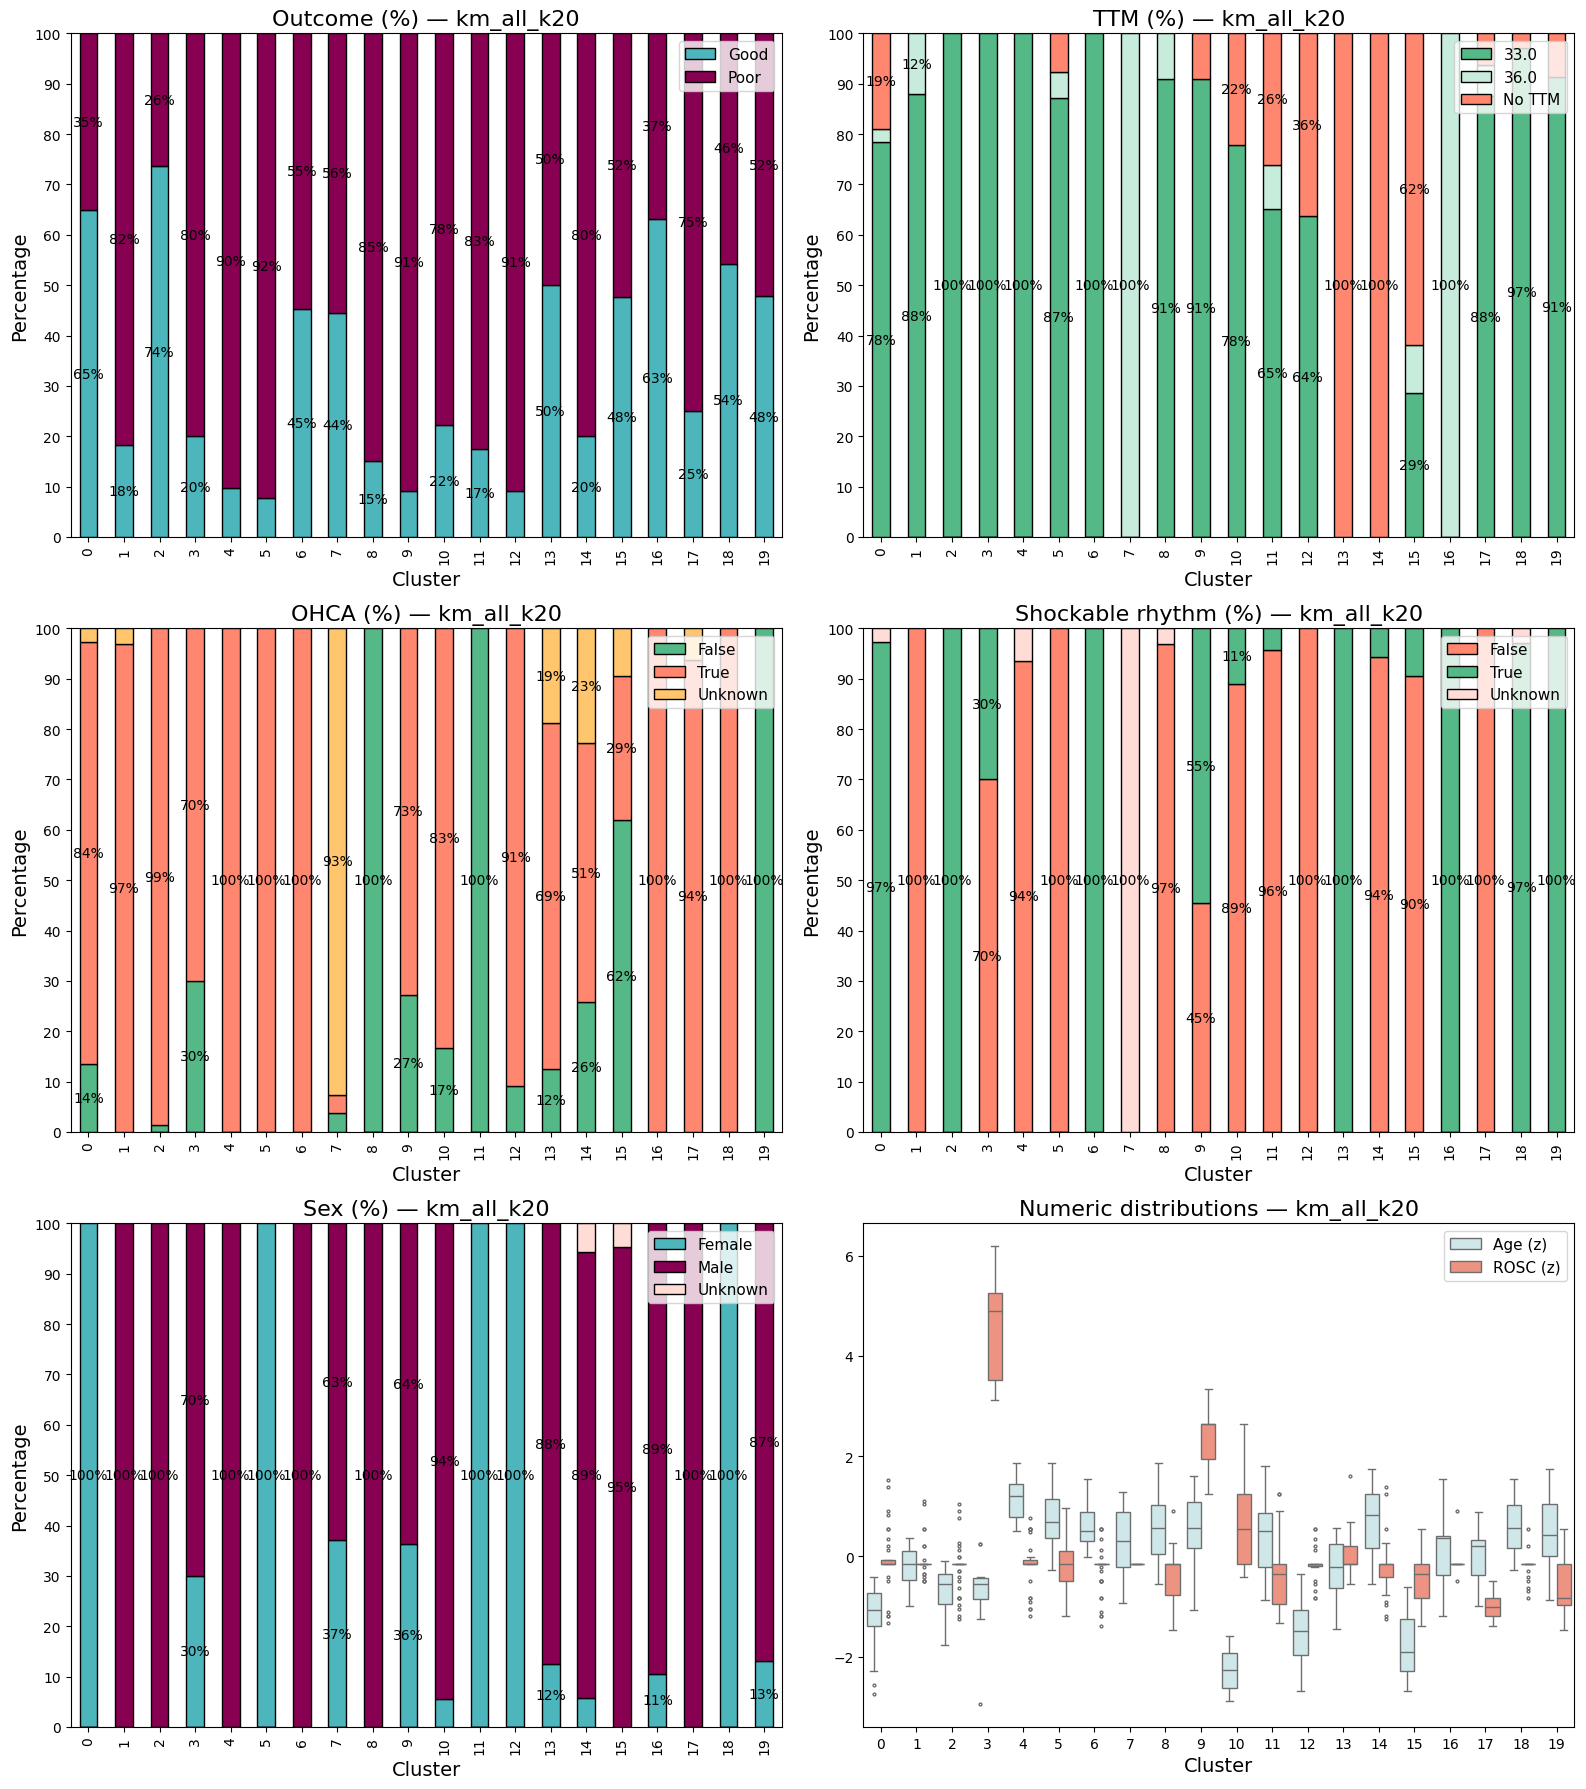

4 Clusters - No TTM protocol excluded


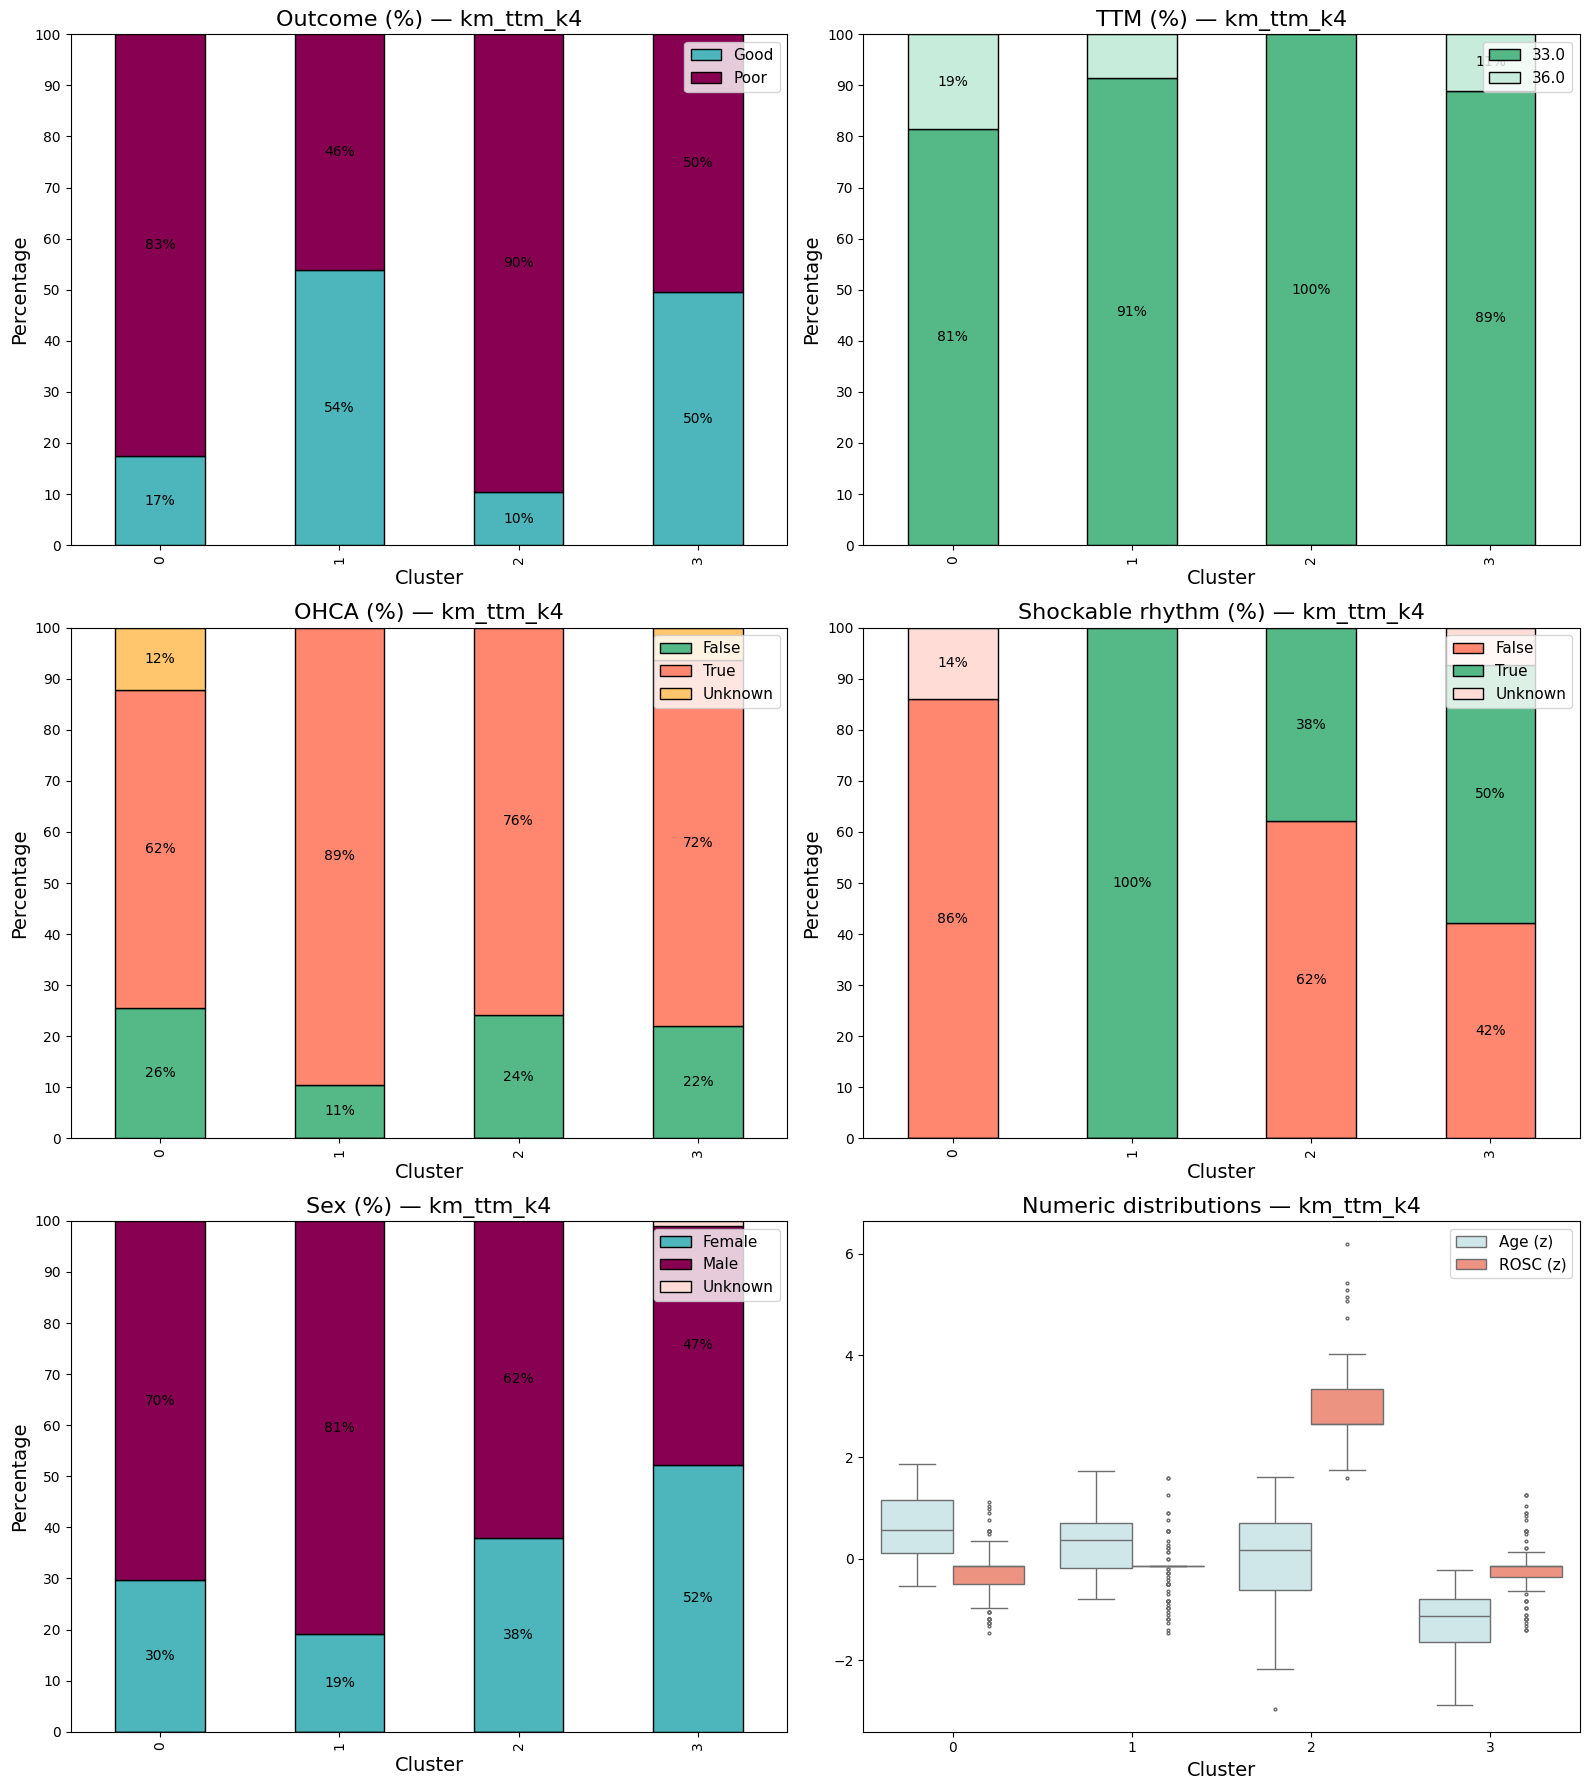

20 Clusters - No TTM protocol excluded


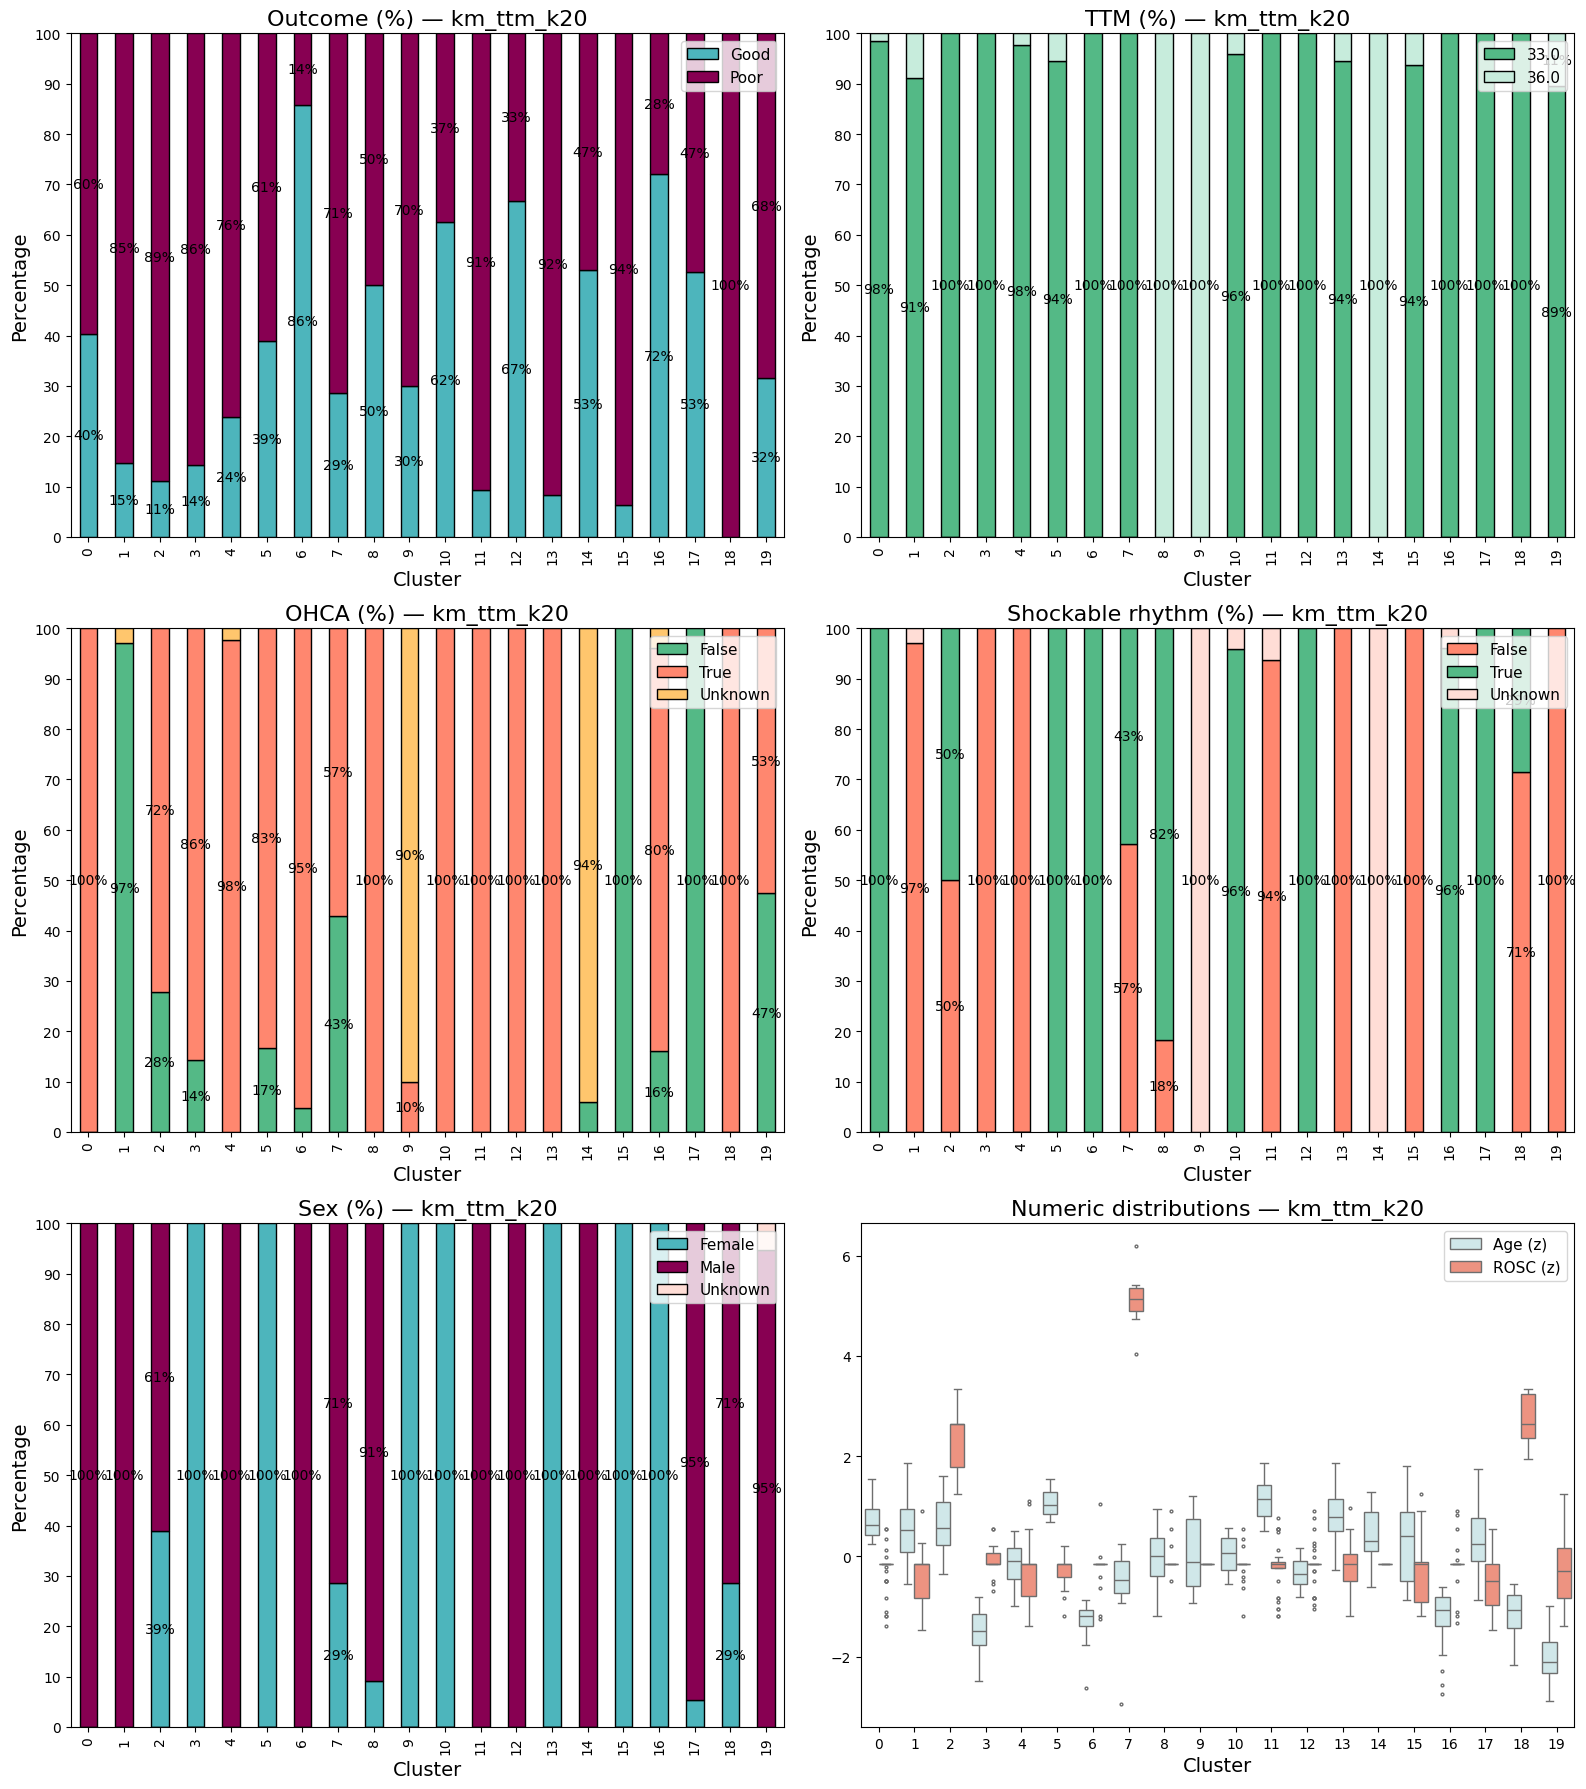

In [22]:
print("4 Clusters - All TTM protocols included")
_ = plot_cluster_summary(df_clusters, "km_all_k4")

print("20 Clusters - All TTM protocols included")
_ = plot_cluster_summary(df_clusters, "km_all_k20")

print("4 Clusters - No TTM protocol excluded")
_ = plot_cluster_summary(df_clusters, "km_ttm_k4")

print("20 Clusters - No TTM protocol excluded")
_ = plot_cluster_summary(df_clusters, "km_ttm_k20")

## Clustering Result Analysis (same as the presentation)

1. There is no distinct separation between clusters.​

2. Across all clusters, the majority of patients are treated with TTM 33, regardless of whether the outcomes are better or worse.​

3. Clusters with worse outcomes tend to have a higher proportion of patients with unshockable rhythms.​

4. In the cluster with a higher proportion of patients with shockable rhythms but worse outcomes, the mean ROSC time is longer.​

### Conclusion from clustering analysis
Patients with unshockable rhythm and have longer rosc time may not benefit from TTM 33.

### Clustering Result Analysis (including no TTM data points)

The stacked bar plots provide insights into the distribution of outcomes (Good vs. Poor) and CPC (Cerebral Performance Category) scores across different clusters. This visualization can help identify patterns in patient outcomes and neurological performance within each cluster. We are now looking for clusters that have an above average performance and neurological result.

---

#### Outcome Percentages by Cluster
- **Cluster 0**: Shows a mix of Good (blue) and Poor (orange) outcomes, with around 60% good outcomes, indicating a relatively balanced prognosis for this group, which is much higher than for most other clusters.
- **Clusters 1-3**: These clusters have a very high percentage of Poor outcomes, suggesting that they represent patients with worse prognoses and higher associated risks.
- **Cluster 4**: Has a more balanced distribution, with approximately 50% Good and 50% Poor outcomes, indicating a mixed-risk group.
- **Clusters 5, 6, 8**: These clusters are dominated by Bad outcomes, especially Cluster 8, which has nearly all Bad outcomes.
- **Cluster 7**: Has a more balanced distribution of almost 50:50 like **Cluster 4**.

#### CPC Percentages by Cluster
- **Cluster 0**: Shows a substantial proportion of CPC score 1 (blue), but also includes a significant amount of CPC score 5 (purple), indicating a range of neurological outcomes within this cluster.
- **Clusters 1-3**: Predominantly have higher CPC scores, especially CPC score 5 (purple), which is indicative of poorer neurological function or outcomes in these groups. Clusters 1 and 2 have minimal lower CPC scores.
- **Cluster 4**: Shows a similar distribution as **Cluster 0** with a few less CPC score 1 and shifted more towards the higher end of the CPP scale.
- **Clusters 5-8**: Display a broader distribution of CPC scores, with higher concentrations of CPC scores 1-3, suggesting moderate neurological outcomes across these clusters.

---
#### Analysis of the resulting clusters
- **Cluster 0**: Contains the highest proportion of patients with out-of-hospital cardiac arrest, around 90%. This cluster includes only male patients, with nearly 90% receiving TTM at 33°C, some at 36°C, and only a small percentage with no TTM. All patients in this cluster had an initial shockable rhythm. The median age is 64 years, placing it on the younger side among higher-age clusters. The median ROSC time is approximately 16 minutes, positioning it around the middle of clusters with shorter ROSC times.

- **Cluster 4**: Comprises about 80% out-of-hospital cardiac arrests and 20% in-hospital cardiac arrests, consisting only of female patients. Around 80% received TTM at 33°C, a few received TTM at 36°C, and about 15% did not receive TTM. Approximately 70% of the patients had a shockable rhythm. The median age is slightly under 47.5, making it one of the younger clusters. The median ROSC time is around 20 minutes, which is slightly above the median for clusters with shorter ROSC times.

- **Cluster 7**: Primarily has unknown cardiac arrest locations and unknown initial ECG rhythms. All patients in this cluster received TTM at 36°C, and around 35% of the patients were female. The median age is 65.5 years, while the average ROSC time is unknown for these patients.
---

### Overall Insights
- **High-Risk Clusters**: Clusters 0,4, and 7 have a higher proportion of better outcomes compared to the other clusters, with **cluster 0** representing the best results.
- **Few good outcome among many bads**: Many clusters are shifted towards the Bad Outcome area. It might be interesting to understand what differentiates the Good Outcomes among the many Bad Outcomes.